In [1]:
import os
import glob

import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import cmocean.cm as cmo
import matplotlib.cm as cm
import matplotlib.lines as mlines

import random
from collections import defaultdict

In [2]:
# Set defaults for Copernicus
plt.rcParams.update({
    'figure.figsize': (6.85, 6.85 * 0.8), # two_col width
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    
    # FIX: Use DejaVu Sans as the primary font to stop the warnings
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'Bitstream Vera Sans']
})

In [3]:
# Load and process data
files = [
    ('plotting-change_point_indices_1.0_40_20_5.csv', r'1$\sigma$ ', '#ffc3d2', '#D791F7'),
    ('plotting-change_point_indices_2.0_40_20_5.csv', r'2$\sigma$ ', '#ff55a0', '#a638bb'),
    ('plotting-change_point_indices_3.0_40_20_5.csv', r'3$\sigma$ ', '#b9005a', '#2f1046')
]

In [4]:
output_dir = '/Data/skd/scratch/innag3580/comp/smoc/'
all_output = glob.glob(os.path.join(output_dir, '*.nc'))
len_final_files = len('smoc55_member_1001.001.nc')
output = [f for f in all_output if len(os.path.basename(f)) == len_final_files]
da_list = [xr.open_dataarray(file) for file in output]
annual_means_list = [da.resample(time='1Y').mean() for da in da_list]

In [5]:
# Load the CSV file containing members to be highlighted in red
path = os.path.join(os.environ['HOME'], 'phase1_CONDA/publishable_code')
filename = 'plotting-change_point_indices_3.0_40_20_5.csv'
file = os.path.join(path, filename)
df = pd.read_csv(file)

In [6]:
counts = df['Condition'].value_counts()
print(df.head())
print(counts)

     Member  Values Condition
0  1001.001      72     Above
1  1001.001     143     Below
2  1001.001     148     Below
3  1001.001     153     Below
4  1011.001     157     Below
Below    194
Above     77
Name: Condition, dtype: int64


In [7]:
filename_2s = 'plotting-change_point_indices_2.0_40_20_5.csv'
file_2s = os.path.join(path, filename_2s)
df_2s = pd.read_csv(file_2s)

In [8]:
df_before_1985 = df_2s[df_2s['Values'] + 1850 < 1985]
counts = df_before_1985['Condition'].value_counts()
print(counts)

Above    341
Below     12
Name: Condition, dtype: int64


# Occurence and time series first

In [9]:
filename = 'plotting-change_point_indices_3.0_40_20_5.csv'
df = pd.read_csv(filename)
members_to_highlight = set(df.loc[df['Condition'] == 'Above', 'Member'].unique())
members_to_highlight_set = {str(member).strip() for member in members_to_highlight}
members_values_dict = defaultdict(list)

bar_width = 1
#positions = np.arange(len(range(1850, 2035, 5)) - 1)
edgecolor_above = '#b9005a'
edgecolor_below = '#2f1046'
colors = cm.viridis_r(np.linspace(0.3, 0.6, len(annual_means_list)))

years = np.arange(1875, 2015, 25)
x_ticks = pd.to_datetime(years, format='%Y')
x_labels = [str(year) for year in years]

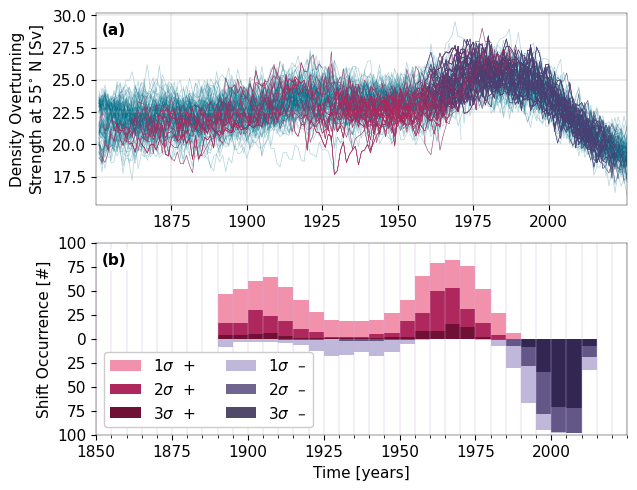

In [11]:


# --- 1. Data Parsing (CRITICAL MISSING PIECE) ---
# This ensures the dictionary is actually filled with the shift years and conditions
members_values_dict = defaultdict(list)
for member, value, condition in zip(df['Member'], df['Values'], df['Condition']):
    cleaned_member = str(member).strip()
    cleaned_condition = condition.strip()  
    members_values_dict[cleaned_member].append((value, cleaned_condition))

# --- 2. Color & Style Definitions ---
color_bg = '#016E89'
pinks = ['#F191AC', '#AE285E', '#701035'] 
purples = ['#B1A7D1', '#4B3F72', '#261C47'] 
color_pink_main = '#AE285E'
color_purple_main = '#4B3F72'

label_props = dict(boxstyle='round,pad=0.2', facecolor='white', alpha=1.0, edgecolor='none')

# Create figure
fig, (ax_1, ax_2) = plt.subplots(2, 1)

# --- 3. First Subplot (ax_1) ---
for idx, (annual_mean, color) in enumerate(zip(annual_means_list, colors)):
    annual_mean_crop = annual_mean.sel(time=slice(None, '2025'))
    # Background ensemble
    annual_mean_crop.plot(ax=ax_1, color=color_bg, alpha=0.3, linewidth=0.5, add_legend=False, zorder=1)
    
    file_name = os.path.basename(output[idx])
    member_id = file_name.split('_')[2].split('.')[0] + '.' + file_name.split('.')[1].strip()
    
    if member_id in members_to_highlight_set:  
        for shift_year, condition in members_values_dict[member_id]:
            start_year = 1850 + shift_year - 5
            
            # Entire 60-year continuous segment
            full_60_year = annual_mean.sel(time=slice(f"{start_year-35}", f"{start_year+20}"))
            
            h_color = color_pink_main if condition == 'Above' else color_purple_main
            
            # Highlight line: 0.3 linewidth, solid
            full_60_year.plot(ax=ax_1, color=h_color, alpha=1.0, linewidth=0.3, linestyle='-', zorder=10)
            
ax_1.set_xlabel('')
ax_1.set_ylabel('Density Overturning\nStrength at 55$^{\circ}$ N [Sv]')
ax_1.text(0.01, 0.95, '(a)', transform=ax_1.transAxes, fontweight='bold', va='top', bbox=label_props, zorder=20)
ax_1.set_xlim(pd.to_datetime('1850-02-01'), pd.to_datetime('2025-12-31'))
ax_1.set_xticks(x_ticks)
ax_1.set_xticklabels(x_labels, ha='center', rotation=0)
ax_1.grid(True, linewidth=0.3)

# --- 4. Second Subplot (ax_2) ---
for i, (filename, label, _, _) in enumerate(files):
    df_bar = pd.read_csv(filename)
    df_bar['Adjusted_Values'] = df_bar['Values'] + 1850
    bins = range(1850, 2025, 5)
    bin_labels = [f"{b}–{b+4}" for b in bins[:-1]]
    df_bar['Value_bins'] = pd.cut(df_bar['Adjusted_Values'], bins=bins, labels=bin_labels, include_lowest=True, right=False)
    
    v_above = df_bar[df_bar['Condition'] == 'Above']['Value_bins'].value_counts().sort_index()
    v_below = df_bar[df_bar['Condition'] == 'Below']['Value_bins'].value_counts().sort_index()
    
    v_above.plot(kind='bar', ax=ax_2, color=pinks[i], width=bar_width, position=0, label=f'{label} +', edgecolor='none')
    (-v_below).plot(kind='bar', ax=ax_2, color=purples[i], width=bar_width, position=0, alpha=0.8, label=f'{label} –', edgecolor='none')

ax_2.set_ylabel('Shift Occurrence [#]')
ax_2.text(0.01, 0.95, '(b)', transform=ax_2.transAxes, fontweight='bold', va='top', bbox=label_props, zorder=10)

# Y-axis absolute range: 100 to -100
ax_2.set_ylim([-100, 100])
y_ticks_vals = [-100, -75, -50, -25, 0, 25, 50, 75, 100]
ax_2.set_yticks(y_ticks_vals)
ax_2.set_yticklabels([str(abs(y)) for y in y_ticks_vals])

ax_2.set_xticks([0, 5, 10, 15, 20, 25, 30])
ax_2.set_xticklabels(['1850', '1875', '1900', '1925', '1950', '1975', '2000'], rotation=0)
ax_2.set_xticks(np.arange(len(range(1850, 2035, 5)) - 1), minor=True)
ax_2.grid(True, which='both', axis='x', color='#cbb2d5', linewidth=0.3)

ax_2.set_xlim([0, 35])
ax_2.set_xlabel('Time [years]')

handles, labels_list = ax_2.get_legend_handles_labels()
ax_2.legend([handles[idx] for idx in [0, 2, 4, 1, 3, 5]], [labels_list[idx] for idx in [0, 2, 4, 1, 3, 5]], 
           loc='lower left', ncol=2, facecolor='white', framealpha=1)

for ax in [ax_2, ax_1]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

plt.savefig('Figure_occurrences.png', bbox_inches='tight', dpi=300, transparent=False, facecolor='white')

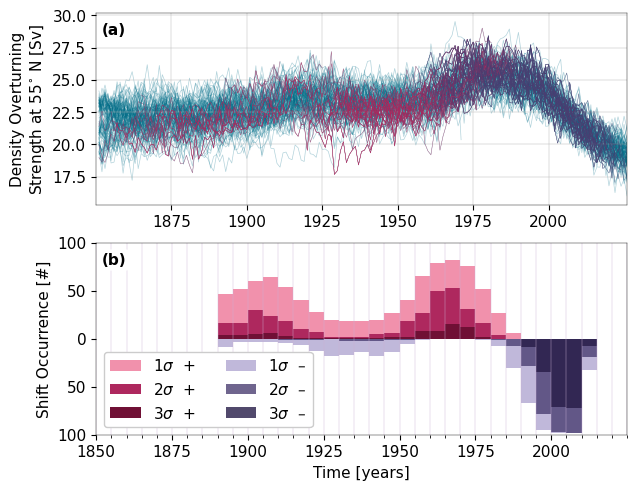

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict

# --- 1. Data Parsing ---
members_values_dict = defaultdict(list)
for member, value, condition in zip(df['Member'], df['Values'], df['Condition']):
    cleaned_member = str(member).strip()
    cleaned_condition = condition.strip()  
    members_values_dict[cleaned_member].append((value, cleaned_condition))

# --- 2. Color & Style Definitions ---
color_bg = '#016E89'
pinks = ['#F191AC', '#AE285E', '#701035'] 
purples = ['#B1A7D1', '#4B3F72', '#261C47'] 
color_pink_main = '#AE285E'
color_purple_main = '#4B3F72'

label_props = dict(boxstyle='round,pad=0.2', facecolor='white', alpha=1.0, edgecolor='none')

# Create figure
fig, (ax_1, ax_2) = plt.subplots(2, 1)

# --- 3. First Subplot (ax_1) ---
for idx, (annual_mean, color) in enumerate(zip(annual_means_list, colors)):
    annual_mean_crop = annual_mean.sel(time=slice(None, '2025'))
    annual_mean_crop.plot(ax=ax_1, color=color_bg, alpha=0.3, linewidth=0.5, add_legend=False, zorder=1)
    
    file_name = os.path.basename(output[idx])
    member_id = file_name.split('_')[2].split('.')[0] + '.' + file_name.split('.')[1].strip()
    
    if member_id in members_to_highlight_set:  
        for shift_year, condition in members_values_dict[member_id]:
            start_year = 1850 + shift_year - 5
            full_60_year = annual_mean.sel(time=slice(f"{start_year-35}", f"{start_year+20}"))
            
            h_color = color_pink_main if condition == 'Above' else color_purple_main
            full_60_year.plot(ax=ax_1, color=h_color, alpha=1.0, linewidth=0.2, linestyle='-', zorder=10)
            
ax_1.set_xlabel('')
ax_1.set_ylabel('Density Overturning\nStrength at 55$^{\circ}$ N [Sv]')
ax_1.text(0.01, 0.95, '(a)', transform=ax_1.transAxes, fontweight='bold', va='top', bbox=label_props, zorder=20)
ax_1.set_xlim(pd.to_datetime('1850-02-01'), pd.to_datetime('2025-12-31'))
ax_1.set_xticks(x_ticks)
ax_1.set_xticklabels(x_labels, ha='center', rotation=0)
ax_1.grid(True, linewidth=0.3)

# --- 4. Second Subplot (ax_2) ---
for i, (filename, label, _, _) in enumerate(files):
    df_bar = pd.read_csv(filename)
    df_bar['Adjusted_Values'] = df_bar['Values'] + 1850
    bins = range(1850, 2025, 5)
    bin_labels = [f"{b}–{b+4}" for b in bins[:-1]]
    df_bar['Value_bins'] = pd.cut(df_bar['Adjusted_Values'], bins=bins, labels=bin_labels, include_lowest=True, right=False)
    
    v_above = df_bar[df_bar['Condition'] == 'Above']['Value_bins'].value_counts().sort_index()
    v_below = df_bar[df_bar['Condition'] == 'Below']['Value_bins'].value_counts().sort_index()
    
    v_above.plot(kind='bar', ax=ax_2, color=pinks[i], width=bar_width, position=0, label=f'{label} +', edgecolor='none')
    (-v_below).plot(kind='bar', ax=ax_2, color=purples[i], width=bar_width, position=0, alpha=0.8, label=f'{label} –', edgecolor='none')

ax_2.set_ylabel('Shift Occurrence [#]')
ax_2.text(0.01, 0.95, '(b)', transform=ax_2.transAxes, fontweight='bold', va='top', bbox=label_props, zorder=10)

# FIXED: Y-axis steps changed to only 0, 50, 100
ax_2.set_ylim([-100, 100])
y_ticks_vals = [-100, -50, 0, 50, 100]
ax_2.set_yticks(y_ticks_vals)
ax_2.set_yticklabels([str(abs(y)) for y in y_ticks_vals])

ax_2.set_xticks([0, 5, 10, 15, 20, 25, 30])
ax_2.set_xticklabels(['1850', '1875', '1900', '1925', '1950', '1975', '2000'], rotation=0)
ax_2.set_xticks(np.arange(len(range(1850, 2035, 5)) - 1), minor=True)
ax_2.grid(True, which='both', axis='x', color='#cbb2d5', linewidth=0.3)

ax_2.set_xlim([0, 35])
ax_2.set_xlabel('Time [years]')

handles, labels_list = ax_2.get_legend_handles_labels()
ax_2.legend([handles[idx] for idx in [0, 2, 4, 1, 3, 5]], [labels_list[idx] for idx in [0, 2, 4, 1, 3, 5]], 
           loc='lower left', ncol=2, facecolor='white', framealpha=1)

for ax in [ax_2, ax_1]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

plt.savefig('Figure_occurrences.png', bbox_inches='tight', dpi=300, transparent=False, facecolor='white')

# detrended time series

In [3]:
# Load the data from the .npy file
data = np.load('spgy_dens_demeaned_series-Copy1.npy')

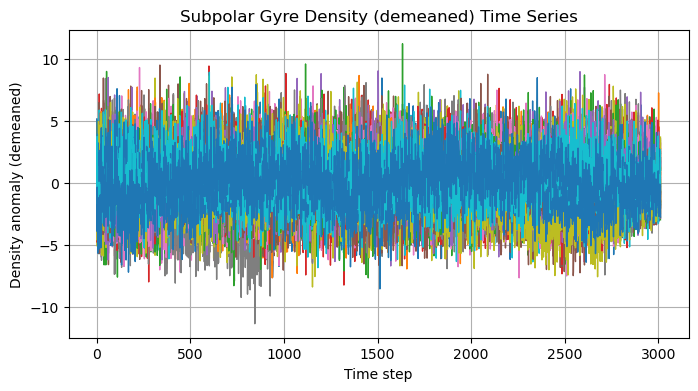

In [4]:

# If it's 1D, we can plot directly
plt.figure(figsize=(8, 4))
plt.plot(data, lw=1)
plt.xlabel('Time step')  # replace with actual time units if known
plt.ylabel('Density anomaly (demeaned)')
plt.title('Subpolar Gyre Density (demeaned) Time Series')
plt.grid(True)
plt.show()

In [10]:
# Parameters
P1_len = 40       
P2_len = 20       
threshold_multiple = 1.0
gap = 5

# Load your detrended series
data = np.load('spgy_dens_demeaned_series-Copy1.npy')

# Calculate annual means (12 months per year)
annual_mean = data.reshape(-1, 12).mean(axis=1)

# Parameters for change‑point detection
P1_len = 40       # baseline window length (years)
P2_len = 20        # change window length (years)
threshold_multiple = 1.0
gap = 20

criteria_indices = []

for j in range(P1_len, len(annual_mean) - P2_len):

    # Compute mean and std of comparison window
    P1 = annual_mean[j - P1_len:j]
    P1_std = P1.std()
    P1_avg = P1.mean()

    # Compute mean of range of interest
    P2 = annual_mean[j:j + P2_len]
    P2_avg = P2.mean()

    # Check if the std is above the threshold
    if P2_avg >= (P1_avg + (threshold_multiple * P1_std)):
        condition = "Above"
    elif P2_avg <= (P1_avg - (threshold_multiple * P1_std)):
        condition = "Below"
    else:
        condition = "Within"

    if condition != "Within":
        if len(criteria_indices) == 0:
            criteria_indices.append((j, condition))
        elif j >= criteria_indices[-1][0] + gap:
            criteria_indices.append((j, condition))

print(criteria_indices)

[]


# senisitvity analysis

In [14]:
def process_file(filename):
    df = pd.read_csv(filename)
    count_above = df[df['Condition'] == 'Above'].shape[0]
    count_below = df[df['Condition'] == 'Below'].shape[0]
    return count_above, count_below

def load_results(output_dir):
    scenario_groups = {
        (40, 20, 10): {'above': [], 'below': [], 'styles': []},
        (20, 20, 10): {'above': [], 'below': [], 'styles': []},
        (40, 20, 5): {'above': [], 'below': [], 'styles': []},
        (20, 20, 5): {'above': [], 'below': [], 'styles': []},
        (40, 20, 20): {'above': [], 'below': [], 'styles': []},
        (20, 20, 20): {'above': [], 'below': [], 'styles': []}
    }

    files = sorted(glob.glob(os.path.join(output_dir, '*.csv')))
    
    i=0
    
    for file in files:
        
        print(file)
        
        if 'detrended' in file:
            detrended = True
        else:
            detrended = False
        
        file_name = os.path.basename(file)
        parts = file_name.replace('.csv', '').replace('change_point_indices_', '').replace('-detrended', '').split('_')
        
        if len(parts) < 4:
            continue  # Skip files without the gap value
        
        try:
            threshold = float(parts[0])
            P1_len = int(parts[1])
            P2_len = int(parts[2])
            gap = int(parts[3])

            if (P1_len, P2_len, gap) in scenario_groups:
                scenario_groups[(P1_len, P2_len, gap)]['above'].append(process_file(file)[0])
                scenario_groups[(P1_len, P2_len, gap)]['below'].append(process_file(file)[1])
                if detrended:
                    scenario_groups[(P1_len, P2_len, gap)]['styles'].append(('D', threshold))
                else:
                    scenario_groups[(P1_len, P2_len, gap)]['styles'].append(('o', threshold))
        except (IndexError, ValueError) as e:
            print(f"Error parsing filename {file_name}: {e}")
    
    return scenario_groups


In [54]:
# Define the output directory and load the results
home_dir = os.environ['HOME']
output_dir = os.path.join(home_dir, 'phase1_CONDA/publishable_code')
scenario_groups = load_results(output_dir)

/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_20_20.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_20_20_10-detrended.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_20_20_10.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_20_20_20-detrended.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_20_20_20.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_20_20_5-detrended.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_20_20_5.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_40_20-detrended.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_1.0_40_20.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_2.0_20_20_10-detrended.csv
/home/innag3580/phase1_CONDA/publishable_code/change_point_indices_2.0_20_20_10.csv
/home/innag3580/phase1_CONDA/publisha

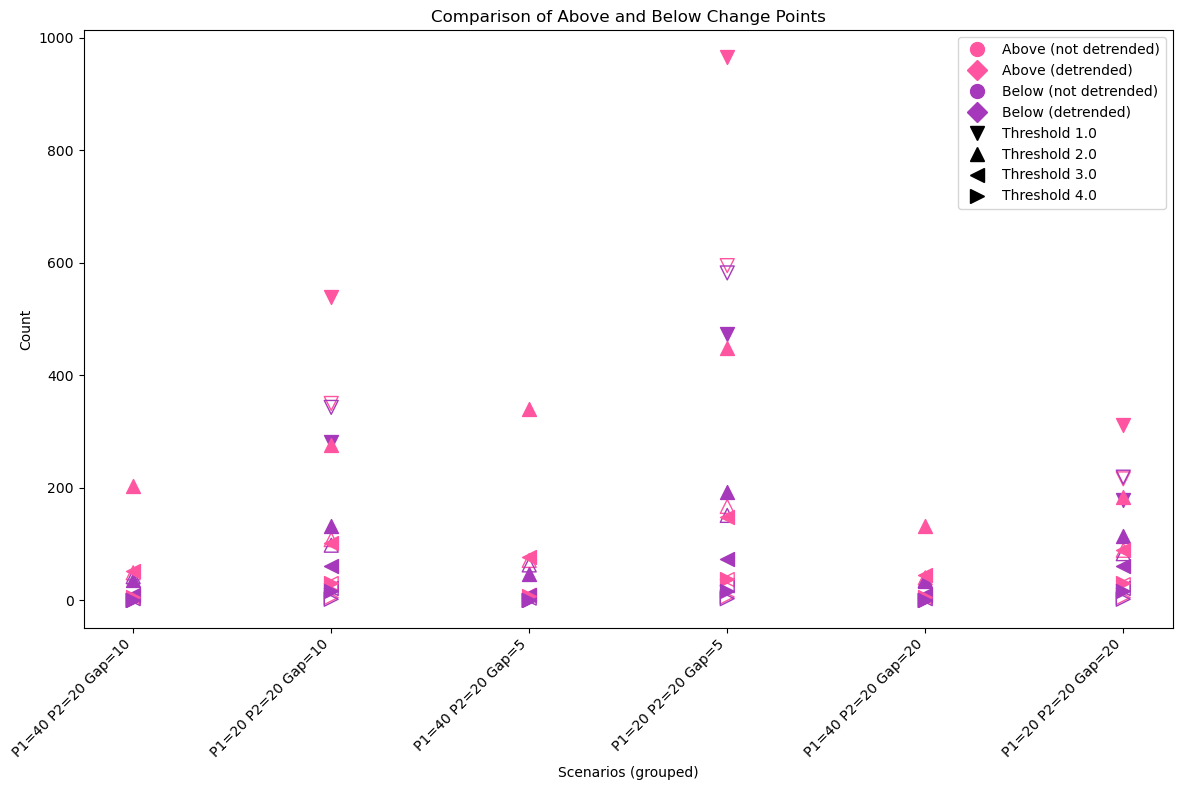

In [57]:
fig, ax = plt.subplots(figsize=(12, 8))  # Width=12 inches, Height=8 inches

colors = {'Above': '#ff55a0', 'Below': '#a638bb'}
markers = {1.0: 'v', 2.0: '^', 3.0: '<', 4.0: '>'}  # Different shapes for thresholds
marker_size = 100  # Adjust this value to increase/decrease marker size

scenario_index = 0
scenario_labels = []

for scenario, data in scenario_groups.items():
    for i in range(len(data['above'])):
        marker_style, threshold = data['styles'][i]
        if marker_style == 'D':  # Diamond marker for detrended
            ax.scatter(scenario_index, data['above'][i], color=colors['Above'], marker=markers[threshold], facecolors='none', edgecolors=colors['Above'], s=marker_size)
            ax.scatter(scenario_index, data['below'][i], color=colors['Below'], marker=markers[threshold], facecolors='none', edgecolors=colors['Below'], s=marker_size)
        else:  # Circle marker for not detrended
            ax.scatter(scenario_index, data['above'][i], color=colors['Above'], marker=markers[threshold], facecolors=colors['Above'], s=marker_size)
            ax.scatter(scenario_index, data['below'][i], color=colors['Below'], marker=markers[threshold], facecolors=colors['Below'], s=marker_size)

    scenario_labels.append(f"P1={scenario[0]} P2={scenario[1]} Gap={scenario[2]}")
    scenario_index += 1

ax.set_xticks(range(len(scenario_groups)))
ax.set_xticklabels(scenario_labels, rotation=45, ha="right")
ax.set_xlabel('Scenarios (grouped)')
ax.set_ylabel('Count')

# Custom legend
legend_elements = [
    mlines.Line2D([], [], color=colors['Above'], marker='o', linestyle='None', markersize=10, label='Above (not detrended)'),
    mlines.Line2D([], [], color=colors['Above'], marker='D', linestyle='None', markersize=10, label='Above (detrended)'),
    mlines.Line2D([], [], color=colors['Below'], marker='o', linestyle='None', markersize=10, label='Below (not detrended)'),
    mlines.Line2D([], [], color=colors['Below'], marker='D', linestyle='None', markersize=10, label='Below (detrended)')
]

for threshold in markers:
    legend_elements.append(mlines.Line2D([], [], color='black', marker=markers[threshold], linestyle='None', markersize=10, label=f'Threshold {threshold}'))

ax.legend(handles=legend_elements, loc='upper right')
ax.set_title('Comparison of Above and Below Change Points')

plt.tight_layout()
plt.show()